# 001 Genre and Spread Analysis

This notebook contains the analysis conducted for section 2 and 3 (results) part 1.

# Genre Analysis

Author: Martín López De Ipiña

This Notebook contains the genre analysis over the movie plot embeddings with the genres already calculated. It contains the following analyses:
- Genre drift and acceleration
- Inter-genre analysis


## Data imports
We import the movie embeddings dataset and we can fileter by top genres, starting year and years per group.

For example, lets keep the 3 genres with the most amount of movies (action, comedy and drama), starting from the 1930s and 3 years per genre group.

In [1]:
import sys, os
from pathlib import Path
notebook_dir = Path().resolve()
base_path = os.path.abspath(notebook_dir.parent.parent)
sys.path.append(base_path)
from src.utils.data_utils import expand_by_genre, map_genre_ids_to_strings, drop_nan_in_column, keep_top_n_genres, \
    load_final_data_with_embeddings
from src.aab_analysis.normalization_strategy import MinGroupSizeDownsampling, ZScoreNormalization, NoNormalization
from src.aab_analysis.math_functions.cosine_distance_util import get_average_embedding, get_medoid_embedding
from src.aab_analysis.stats_data import plot_genre_drift, plot_mean_convergence
from src.aab_analysis.genre_drift_utils import calculate_drift_metrics

DATA_DIR = os.path.join(base_path, "data", "data_final")

GENRE_MAP_JSON_PATH = os.path.join(base_path, "src", "config", "cluster_to_genre_mapping_01122025.json")

RANDOM_SEED = 42
START_YEAR = 1930
BIN_SIZE = 3
TOP_K_GENRES = 3

df = load_final_data_with_embeddings(
    csv_path=f"{DATA_DIR}/final_dataset.csv",
    data_dir=DATA_DIR
)
print(df.shape)

# Drop if genre is nan
df = drop_nan_in_column(df=df, column_name="new_genre")
print(df.shape)

# Expand the movies: if it has 2 genres then repeat it 2 times one per each genre
df = expand_by_genre(df)
print(df.shape)

# Map so instead of Genre identifiers we have the genre name
df = map_genre_ids_to_strings(df, GENRE_MAP_JSON_PATH)
print(df.shape)

df = keep_top_n_genres(df, TOP_K_GENRES)
print(df.shape)

# Limit years
df = df[df["year"] >= START_YEAR]

/home/martin/anaconda3/envs/dataLiteracy/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(92374, 39)
(79984, 39)
(122968, 39)
(122968, 39)
(62480, 40)


## Genre drift Metrics
Here we calculate genre drift, genre acceleration and genre drift cumulative change.

Embeddings are first grouped by genre $g$ into discrete time periods $\tau$, forming the set $\mathcal{M}_g^{(\tau)}$ of plot embeddings. For each group, two alternative representative embeddings are computed: the centroid (arithmetic mean) $\bar{\mathbf{e}}_g^{(\tau)}$ and the medoid (cosine distance minimizer embedding) $\tilde{\mathbf{e}}_g^{(\tau)}$.

Genre drift measures displacement between representative embeddings of consecutive periods, capturing how a genre's semantic center evolves over time. Acceleration quantifies the change in drift between consecutive periods.

$$
\mathbf{d}_g^{(\tau)} = \bar{\mathbf{e}}_g^{(\tau + \Delta t)} - \bar{\mathbf{e}}_g^{(\tau)}
$$

### Genre drift

Lets first compare the genre drift with no normalization vs downsampling.

The first plot suggests that movies are changing less as years go by, since the distance change in later years is much smaller, but after downsampling no apparent pattern can be seen.


Calculating drift_acceleration: 100%|██████████| 96/96 [00:00<00:00, 66106.25it/s]


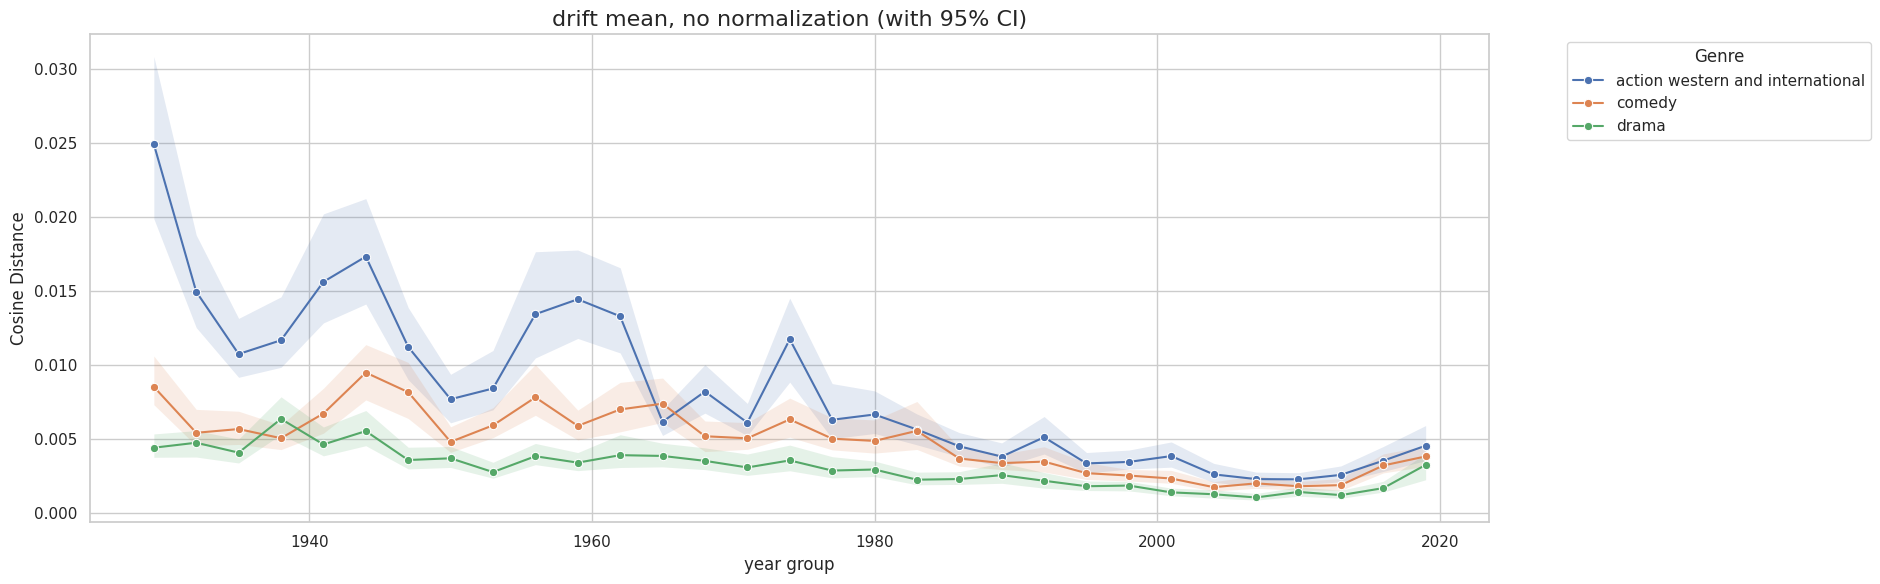

[MinGroupSizeDownsampling] Downsampling all groups to 54 samples


/home/martin/GroupDataLiteracy/src/aab_analysis/normalization_strategy.py:128: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(len(x), min_size), random_state=random_seed))
Calculating drift_acceleration: 100%|██████████| 96/96 [00:00<00:00, 69208.18it/s]


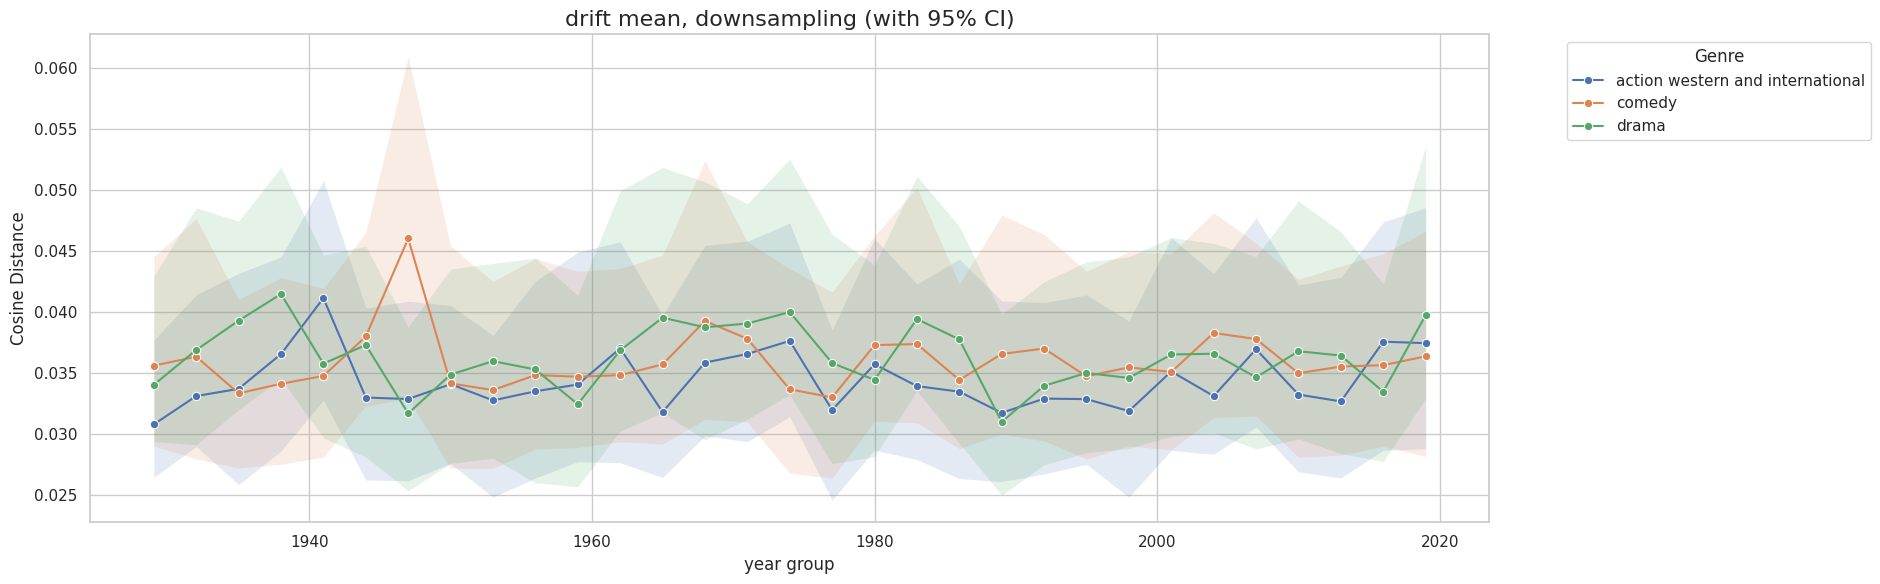

In [2]:
N_BOOTSTRAP_SAMPLES = 100

drift_df_mean_no_norm = calculate_drift_metrics(
    df=df,
    n_years_per_group=BIN_SIZE,
    grouping_function=get_average_embedding,
    n_boostrap_samples=N_BOOTSTRAP_SAMPLES,
    normalization_strategy=NoNormalization()
)
plot_genre_drift(
    df=drift_df_mean_no_norm,
    y_column='drift_velocity',
    title="drift mean, no normalization",
    y_label='Cosine Distance'
)

drift_df_mean = calculate_drift_metrics(
    df=df,
    n_years_per_group=BIN_SIZE,
    grouping_function=get_average_embedding,
    n_boostrap_samples=N_BOOTSTRAP_SAMPLES,
    normalization_strategy=MinGroupSizeDownsampling()
)
plot_genre_drift(
    df=drift_df_mean,
    y_column='drift_velocity',
    title="drift mean, downsampling",
    y_label='Cosine Distance'
)

We can also try with the medoid

[MinGroupSizeDownsampling] Downsampling all groups to 54 samples


/home/martin/GroupDataLiteracy/src/aab_analysis/normalization_strategy.py:128: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(len(x), min_size), random_state=random_seed))
Calculating drift_acceleration: 100%|██████████| 96/96 [00:00<00:00, 71876.68it/s]


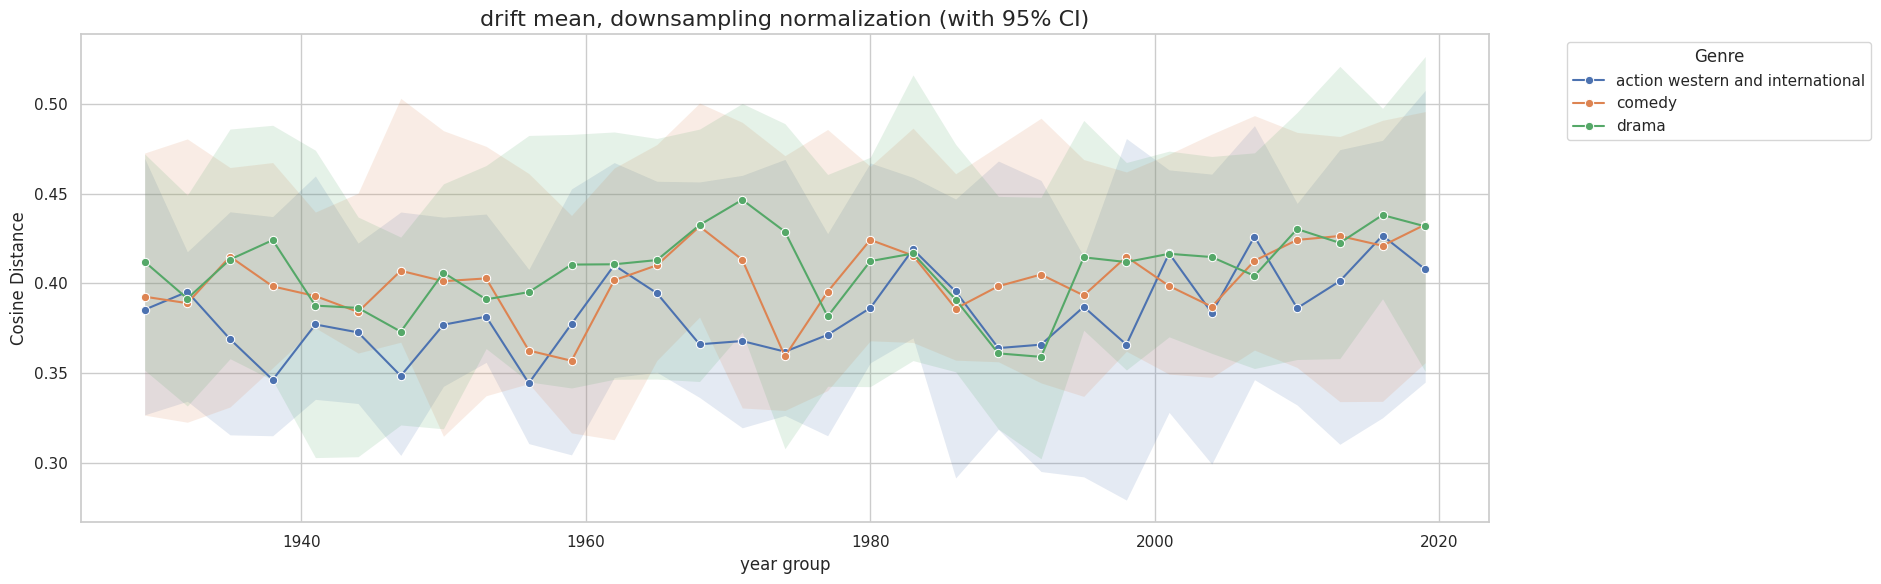

In [3]:
drift_df_medoid_min_norm = calculate_drift_metrics(
    df=df,
    n_years_per_group=BIN_SIZE,
    grouping_function=get_medoid_embedding,
    n_boostrap_samples=N_BOOTSTRAP_SAMPLES,
    normalization_strategy=MinGroupSizeDownsampling()
)
plot_genre_drift(
    df=drift_df_medoid_min_norm,
    y_column='drift_velocity',
    title="drift mean, downsampling normalization",
    y_label='Cosine Distance'
)

# Genre drift acceleration

Since the drift did not yield any results, lets check the acceleration (drift of the drift).

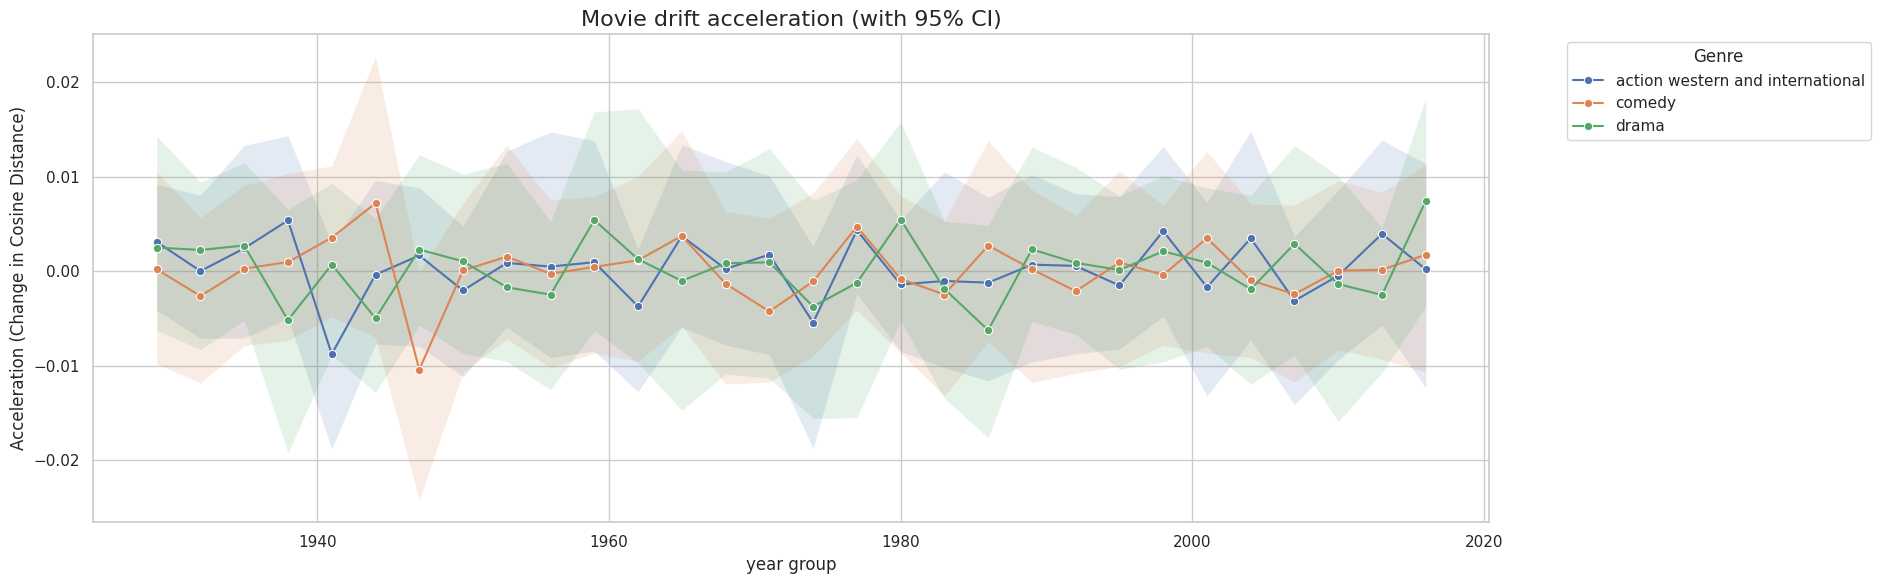

In [4]:
plot_genre_drift(
    df=drift_df_mean,
    y_column='drift_acceleration',
    title=f'Movie drift acceleration',
    y_label='Acceleration (Change in Cosine Distance)',
    softness_window=1
)


# Inter-genre analysis

We can now compare the cosine distance between different genre's representative embedding over time. For example, the first plot shows the cosine distance of action movies with respect to drama and action time.

[Downsampling] All groups to 54 samples


/home/martin/GroupDataLiteracy/src/aab_analysis/stats_data.py:533: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(len(x), min_size), random_state=random_seed))


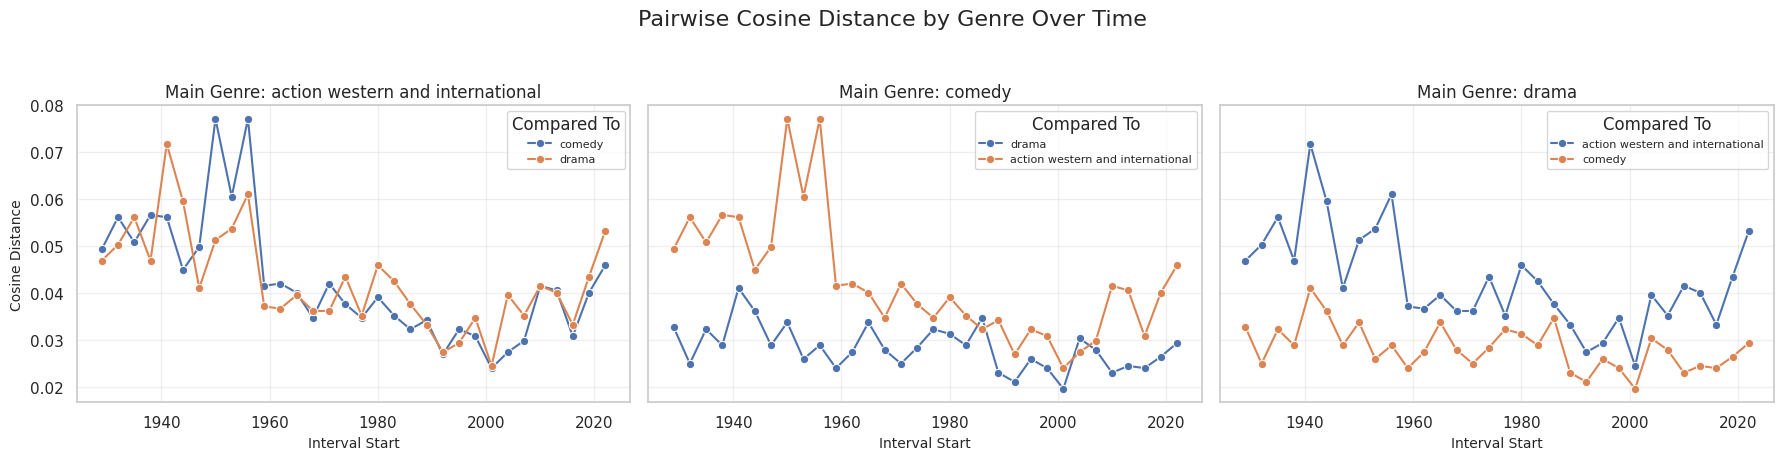

In [6]:
from src.aab_analysis.stats_data import calculate_genre_convergence, plot_pairwise_convergence

convergence_df = calculate_genre_convergence(
    df=df,
    bin_size=BIN_SIZE,
    downsample=True,
)

plot_pairwise_convergence(convergence_df)